VAE Image Generation

## Table of Contents

- [Import Libraries and Load Data](#import-libraries-and-load-data)
- [Define Model](#define-model)
    - [VAE Loss Function](#vae-loss-function)
- [Train Model](#train-model)
- [Plot Loss](#plot-loss)
- [Image Reconstruction Sample](#image-reconstruction)
- [Image Generation Sample](#image-generation)

## Import Libraries and Load Data

In [55]:
import cv2
import matplotlib.pyplot as plt
import random
import zipfile
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import unittest
import time
from torch.autograd import Variable
from scipy.stats import shapiro
from tqdm import tqdm

In [56]:
image_dir = 'dataset/cats/data'

print("Contents of the 'data' directory:")
print(os.listdir(image_dir))

image_files = [f for f in os.listdir(image_dir) if f.endswith(('png', 'jpg', 'jpeg'))]

num_images = len(image_files)
print(f'Number of images: {num_images}')

Contents of the 'data' directory:
['cat_0.png', 'cat_1.png', 'cat_10.png', 'cat_100.png', 'cat_1000.png', 'cat_10000.png', 'cat_10001.png', 'cat_10002.png', 'cat_10003.png', 'cat_10004.png', 'cat_10005.png', 'cat_10006.png', 'cat_10007.png', 'cat_10008.png', 'cat_10009.png', 'cat_1001.png', 'cat_10010.png', 'cat_10011.png', 'cat_10012.png', 'cat_10013.png', 'cat_10014.png', 'cat_10015.png', 'cat_10016.png', 'cat_10017.png', 'cat_10018.png', 'cat_10019.png', 'cat_1002.png', 'cat_10020.png', 'cat_10021.png', 'cat_10022.png', 'cat_10023.png', 'cat_10024.png', 'cat_10025.png', 'cat_10026.png', 'cat_10027.png', 'cat_10028.png', 'cat_10029.png', 'cat_1003.png', 'cat_10030.png', 'cat_10031.png', 'cat_10032.png', 'cat_10033.png', 'cat_10034.png', 'cat_10035.png', 'cat_10036.png', 'cat_10037.png', 'cat_10038.png', 'cat_10039.png', 'cat_1004.png', 'cat_10040.png', 'cat_10041.png', 'cat_10042.png', 'cat_10043.png', 'cat_10044.png', 'cat_10045.png', 'cat_10046.png', 'cat_10047.png', 'cat_10048.png

First image shape: (64, 64, 3)


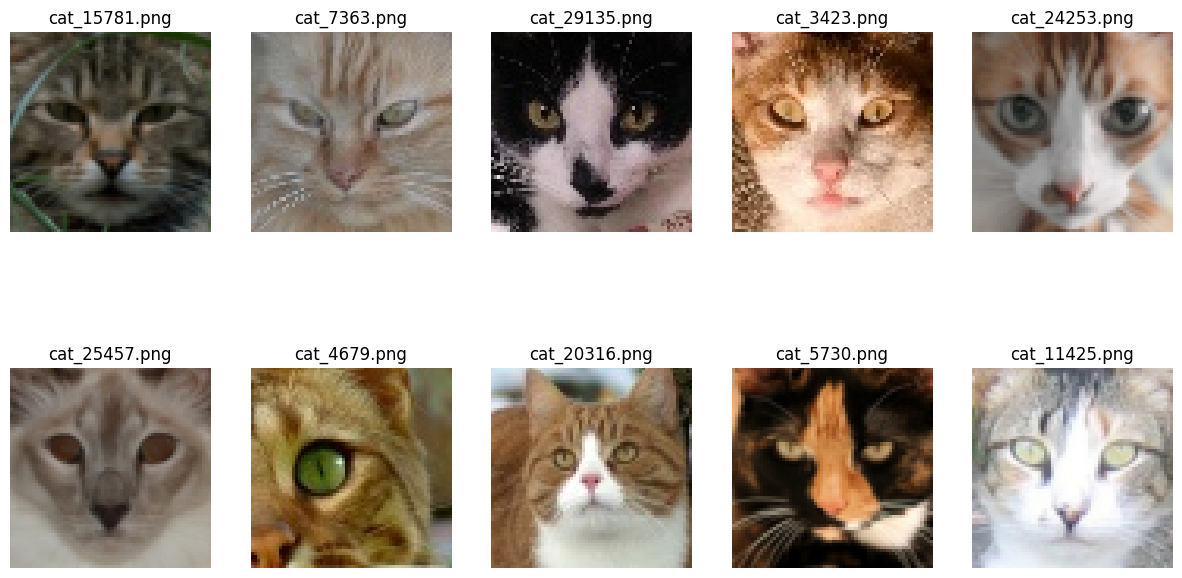

In [3]:
if num_images > 0:
    first_image_path = os.path.join(image_dir, image_files[0])
    first_image = cv2.imread(first_image_path)

    print(f'First image shape: {first_image.shape}')

    def plot_random_images(image_files, num_images=10):
        plt.figure(figsize=(15, 8))
        random_files = random.sample(image_files, num_images)
        for i, file in enumerate(random_files):
            img_path = os.path.join(image_dir, file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(2, 5, i + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(file)
        plt.show()

    plot_random_images(image_files, num_images=10)
else:
    print("No images found in the specified directory.")

In [57]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, transform=None):
        self.image_files = image_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(image_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

In [58]:
custom_data = CustomImageDataset(image_files, transform=transform)
data_loader = DataLoader(custom_data, batch_size=64, shuffle=True, num_workers=0)

## Define Model

In [59]:
H_DIM = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [ ]:
class VAE(nn.Module):
    def __init__(self, h_dim=H_DIM):
        super(VAE, self).__init__()

        #Encoder Convs
        # 3 convolutional layers with increasing number of filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=4, padding=1, stride=2)    # 32*128*128
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, padding=1, stride=2)   # 64*64*64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, padding=1, stride=2)  # 128*32*32

        self.flatten = nn.Flatten()

        # These dims must match input size after convs
        self.fc_mu = nn.Linear(32 * 32 * 128, h_dim)
        self.fc_logvar = nn.Linear(32 * 32 * 128, h_dim)

        self.fc_decode = nn.Linear(h_dim, 32 * 32 * 128)

        # Decoder
        self.deconv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, padding=1, stride=2)
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, padding=1, stride=2)
        self.deconv3 = nn.ConvTranspose2d(32, 3,kernel_size=4, padding=1, stride=2)


    def reparameterize(self, mu, logvar):
        # Sample epsilon from standard normal, compute std from logvar, and return z = mu + std * eps
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps


    def sample(self, num_samples, device=DEVICE):
        self.eval()

        # Sample from standard
        z = torch.randn(num_samples, H_DIM).to(device)
        
        with torch.no_grad():
            # Generate images from sampled z
            # decode the sampled z to images
            z = F.relu(self.fc_decode(z))
            z = z.view(-1, 128, 32, 32)
            z = F.relu(self.deconv1(z))
            z = F.relu(self.deconv2(z))

            generated_images = torch.sigmoid(self.deconv3(z))

        return generated_images

    def forward(self, x):

        # Encoder 
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        # sample z
        z = self.reparameterize(mu, logvar)

        # Decoder
        x = F.relu(self.fc_decode(z))
        x = x.view(-1, 128, 32, 32)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = torch.sigmoid(self.deconv3(x))
        return x, mu, logvar


### VAE Loss Function

In [ ]:
def loss_function(recon_x, x, mu, logvar):
    # BCE + KLD loss
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    batch_size = x.size(0) # Use batch size to normalize loss values
    BCE /= batch_size
    KLD /= batch_size
    
    return BCE + KLD, BCE, KLD

## Train Model

In [ ]:
def train(epoch, model, optimizer, train_loader, history):
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kld_loss_total = 0

    # for batch_idx, data in enumerate(train_loader):
    for data in tqdm(train_loader, leave=False):
        data = data.to(DEVICE)
        data = data.float()
        optimizer.zero_grad()

        # use model for reconstruction and get mu, logvar and calculate loss
        recon_data, mu, logvar = model(data)
        loss, recon_loss, kld_loss = loss_function(recon_data, data, mu, logvar)

        loss.backward()
        train_loss += loss.item()
        recon_loss_total += recon_loss.item()
        kld_loss_total += kld_loss.item()

        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = recon_loss_total / len(train_loader.dataset)
    avg_kld = kld_loss_total / len(train_loader.dataset)


    history['total_loss'].append(avg_loss)
    history['recon_loss'].append(avg_recon)
    history['kld_loss'].append(avg_kld)

    print(f'====> Epoch: {epoch} Average Loss: {avg_loss:.4f} (BCE: {avg_recon:.4f}, KL: {avg_kld:.4f})')

In [ ]:
# Training parameters

EPOCHS = 50
LR = 0.001

if __name__ == '__main__':    
    model = VAE().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    history = {'total_loss': [], 'recon_loss': [], 'kld_loss': []}

    print("Start training...")
    for epoch in range(1, EPOCHS + 1):
        train(epoch, model, optimizer, data_loader, history)

    print("Finish training.")

Start training...


====> Epoch: 1 Average Loss: 1813.8396 (BCE: 1810.1734, KL: 3.6662)


====> Epoch: 2 Average Loss: 1721.7893 (BCE: 1717.0680, KL: 4.7213)


====> Epoch: 3 Average Loss: 1707.9381 (BCE: 1702.9101, KL: 5.0280)


====> Epoch: 4 Average Loss: 1700.5542 (BCE: 1695.3862, KL: 5.1680)


...

====> Epoch: 46 Average Loss: 1672.9910 (BCE: 1667.7146, KL: 5.2764)


====> Epoch: 47 Average Loss: 1672.9872 (BCE: 1667.7086, KL: 5.2786)


====> Epoch: 48 Average Loss: 1672.6869 (BCE: 1667.4096, KL: 5.2774)


====> Epoch: 49 Average Loss: 1672.9182 (BCE: 1667.6389, KL: 5.2792)


====> Epoch: 50 Average Loss: 1672.5719 (BCE: 1667.2940, KL: 5.2779)
Finish training.


In [ ]:
# Save model weights
torch.save(model.state_dict(), "vae_model_weights.pth")


# Load model with weights
# model = VAE()
# state_dict = torch.load("vae_model_weights.pth", map_location=DEVICE)
# model.load_state_dict(state_dict)
# model = model.to(DEVICE)

## Plot Loss

In [ ]:
def plot_history(history):
    epochs = np.arange(1, len(history["total_loss"]) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["total_loss"])
    plt.title("Total Loss")

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["recon_loss"])
    plt.title("Reconstrcution Loss")
    
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["kld_loss"])
    plt.title("KLD Loss")
    
    plt.show()


def display_and_compare_images(img_original, img_reconstructed):
    plt.figure(figsize=(7, 4))
    
    plt.subplot(1, 2, 1)
    plt.axis('off')
    plt.imshow(img_original)
    plt.title('Original Image')
    
    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.imshow(img_reconstructed)
    plt.title('Reconstructed Image')
    
    plt.tight_layout()
    plt.show()

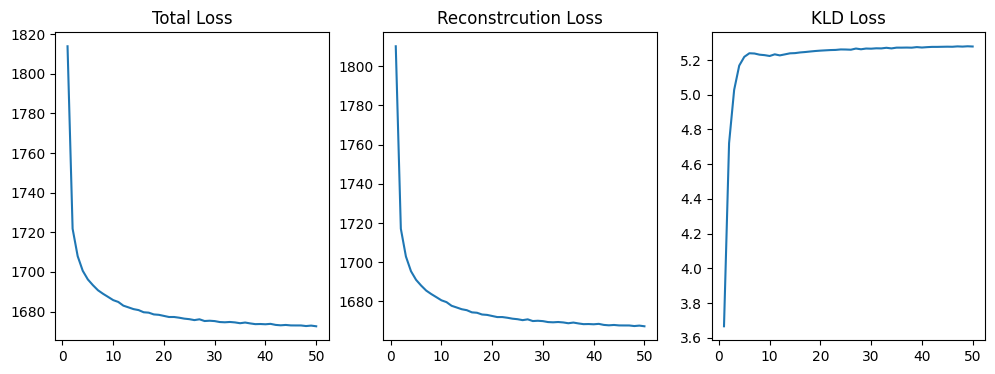

In [22]:
plot_history(history)

## Image Reconstruction

In [67]:
# Example of retrieving a random sample from the dataset
import random

dataset = data_loader.dataset 

random_index = random.randint(0, len(dataset) - 1)

num_samples = 8
indices = random.sample(range(len(dataset)), num_samples)

sampled_images = [dataset[i] for i in indices]

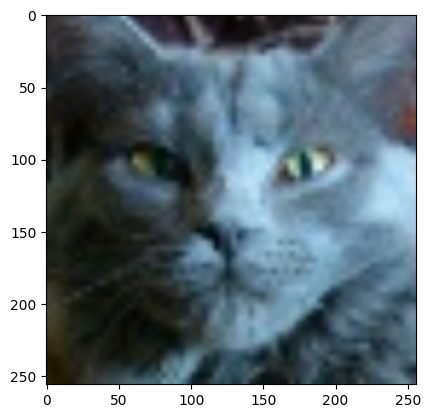

In [68]:
#Visualize the test_data image
plt.imshow(np.transpose(sampled_images[0].cpu().numpy(), (1,2,0)))
plt.show()

In [ ]:
# Generate reconstructions for the sampled images

model.eval()
# recon_images = []

with torch.no_grad():
    sampled_images = torch.stack(sampled_images)
    sampled_images = sampled_images.to(DEVICE)
    sampled_images = sampled_images.float()
    recon_images, _, _ = model(sampled_images)


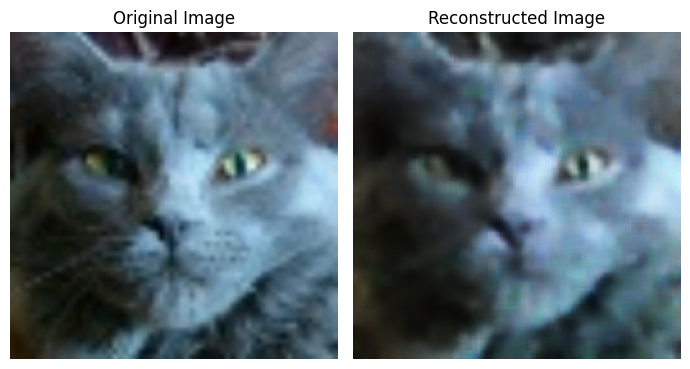

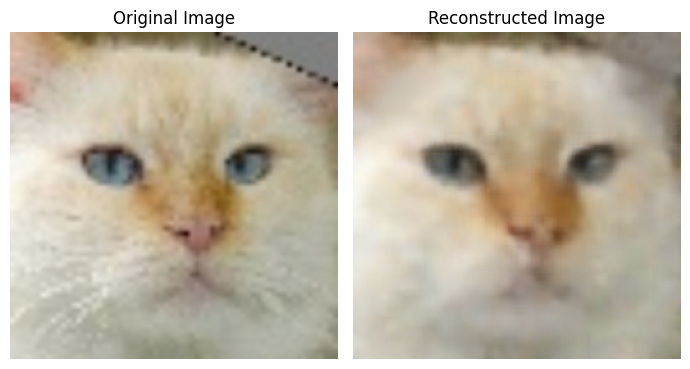

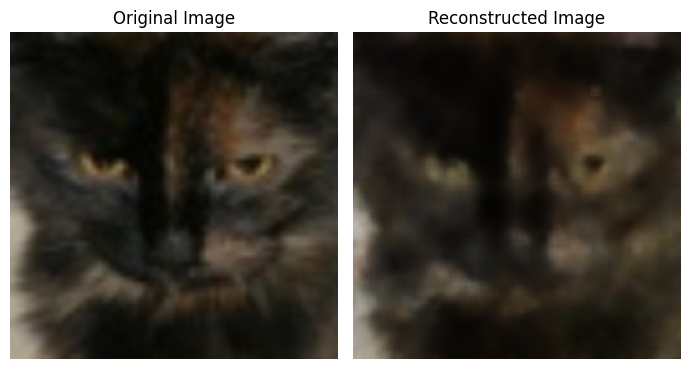

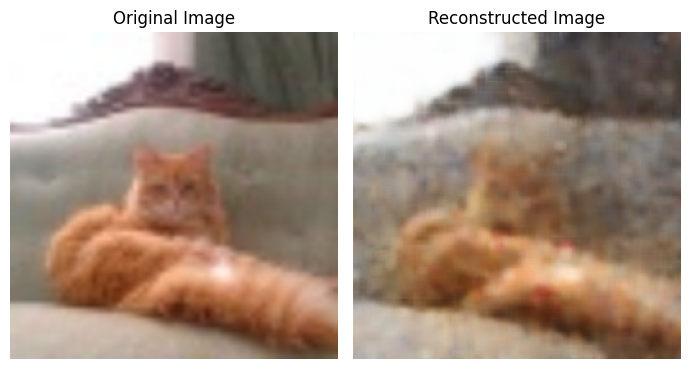

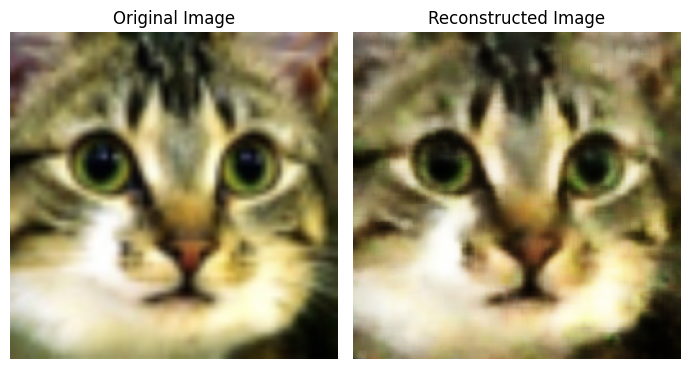

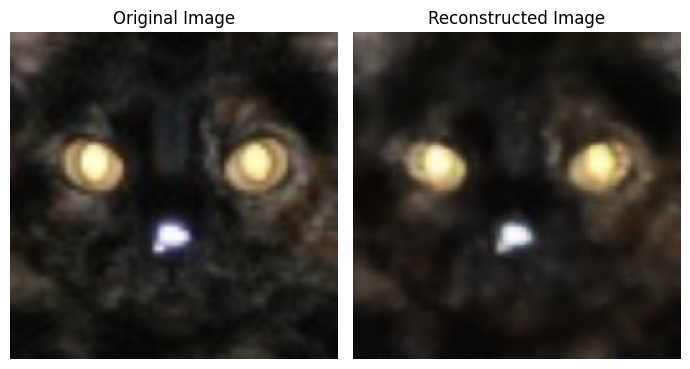

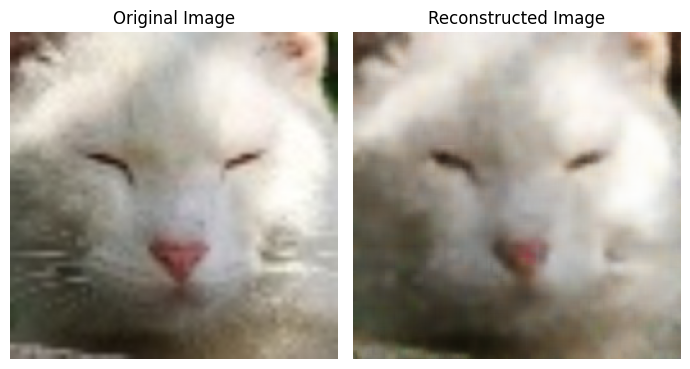

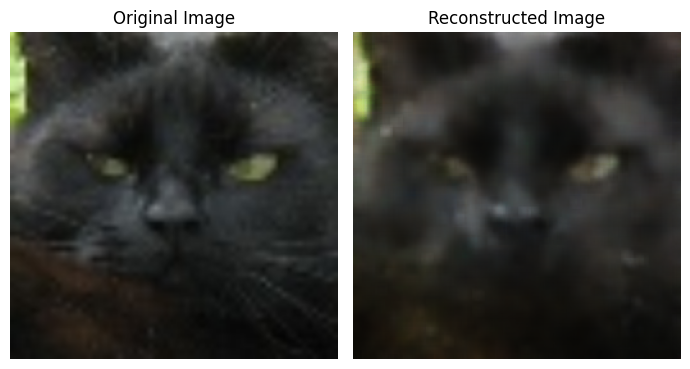

In [73]:
for img, img_recon in zip(sampled_images, recon_images):
    img = np.transpose(img.cpu().numpy(), (1,2,0))
    img_recon = np.transpose(img_recon.cpu().numpy(), (1,2,0))
    display_and_compare_images(img, img_recon)


## Image Generation

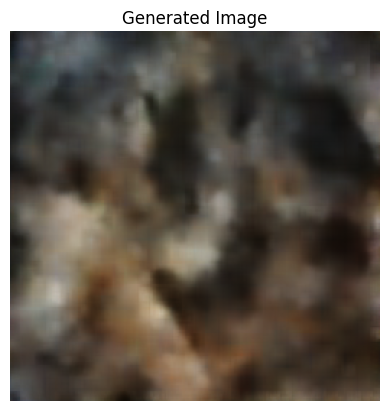

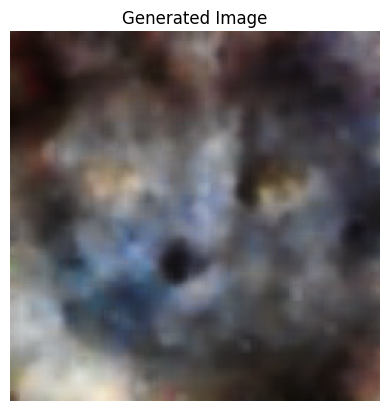

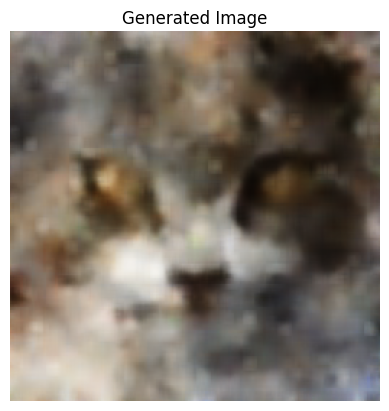

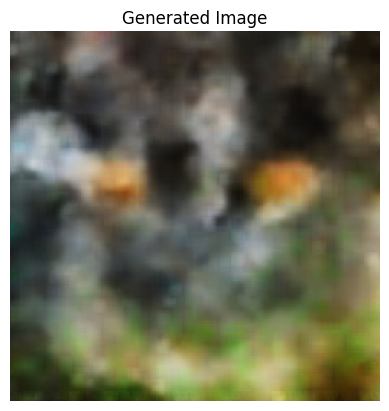

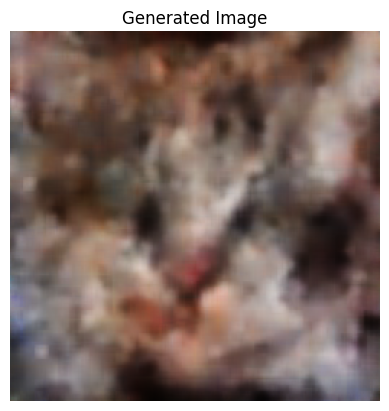

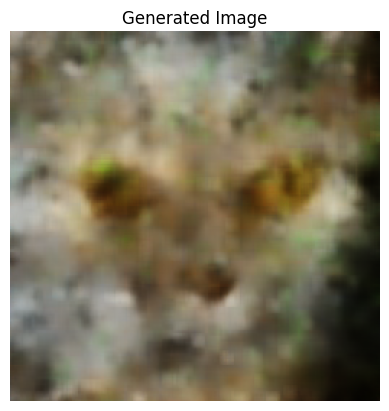

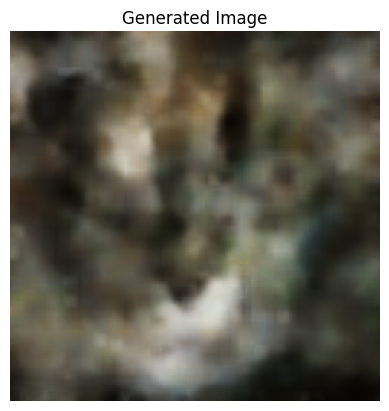

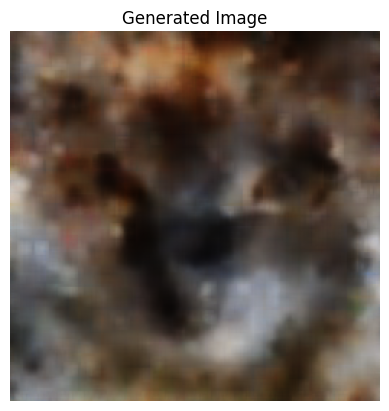

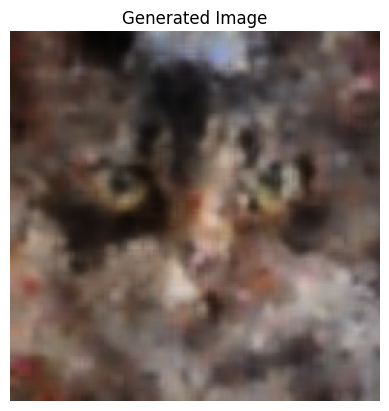

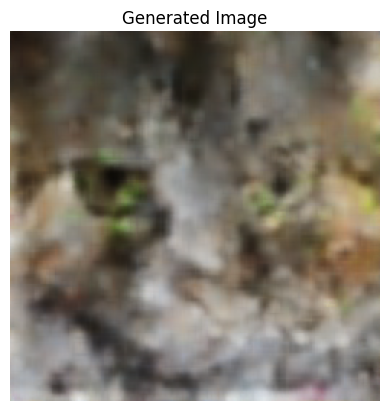

In [ ]:
# Generate new images by sampling from the latent space
generated_images = model.sample(10)

for img in generated_images:
    img = np.transpose(img.cpu().numpy(), (1,2,0))
    plt.axis('off')
    plt.imshow(img)
    plt.title('Generated Image')
    plt.show()